In [178]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [179]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [180]:
from src.data_loader import *

df = load_data("../data/raw/dataset-diabete.csv")
df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33


In [181]:
df.shape

(768, 9)

In [182]:
df.columns

Index(['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure',
       'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [184]:
df.describe()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


# Data Dictionary

Source: `data/raw/dataset-diabete.csv` (768 patients, similar to the Pima Indians Diabetes dataset)

| Column | Meaning | Unit | Typical range | Problem in our data | Planned action |
|---|---|---|---|---|---|
| `Unnamed: 0` | Old row index saved by mistake | none | 0 to 767 | No medical meaning | Drop |
| `Pregnancies` | Number of times the patient has been pregnant | count | 0 to 17 | None (0 is valid) | Keep or drop (decide later) |
| `Glucose` | Blood sugar 2 hours after drinking a glucose solution (oral glucose tolerance test) | mg/dL | about 70 to 200 | Zeros are impossible | Zero to NaN, then impute |
| `BloodPressure` | Diastolic blood pressure (the lower number) | mm Hg | about 60 to 90 | Zeros are impossible | Zero to NaN, then impute |
| `SkinThickness` | Triceps skinfold thickness, an indirect measure of body fat | mm | about 10 to 50 | Many zeros (over 25% of rows) | Zero to NaN, then impute |
| `Insulin` | Insulin level in the blood 2 hours after the glucose test | mu U/ml | about 15 to 276 | Many zeros, very skewed, max 846 | Zero to NaN, impute, check outliers |
| `BMI` | Body Mass Index = weight (kg) / height (m)² | kg/m² | 18.5 to 40 | Zeros are impossible | Zero to NaN, then impute |
| `DiabetesPedigreeFunction` | Score of diabetes history in the family, weighted by how close the relatives are | no unit | 0.08 to 2.42 | Right-skewed, possible outliers | Keep, check outliers |
| `Age` | Age of the patient | years | 21 to 81 | Right-skewed | Keep, check outliers |

## Risk thresholds used in the project
- Glucose > 126
- BMI > 30
- DiabetesPedigreeFunction > 0.5

## Notes
- There is no "Outcome" column (diabetic yes/no). That is why we use K-Means to create groups first.
- Zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI mean "not measured".

In [185]:
from src.preprocessing import *
df = drop_column(df,"Unnamed: 0")
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [186]:
from src.eda import *

column_info(df, "Glucose")

,Section,Metric,Value
0,General,Data type,int64
1,General,Total rows,768
2,General,Unique values,136
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,5 (0.7%)
5,Distribution,Min,0
6,Distribution,Max,199
7,Distribution,Mean,120.89
8,Distribution,Median,117.0
9,Distribution,Std deviation,31.97


In [187]:
# df = zeros_to_nan(df, "Glucose")
# column_info(df, "Glucose")

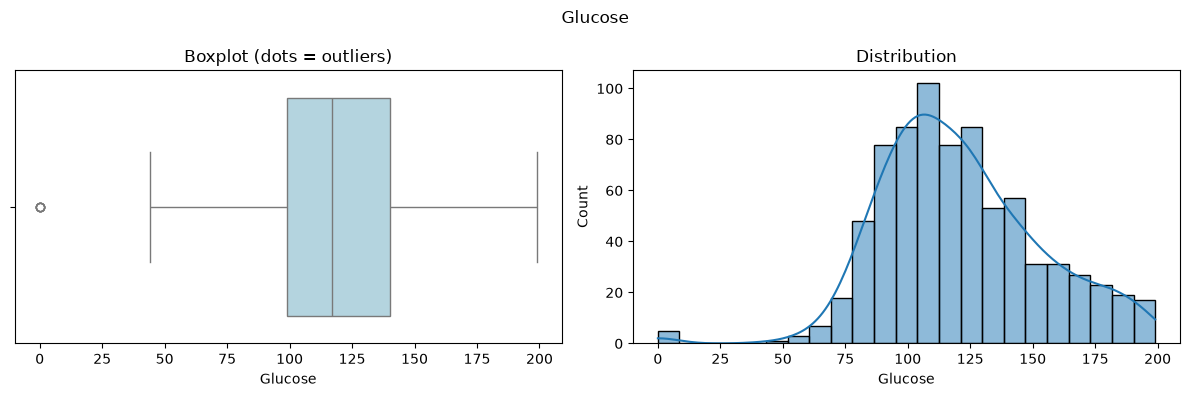

In [188]:
graphe_check_outliers(df, "Glucose")

In [189]:
missing = df["Glucose"].isna()
df.groupby(missing)[["BMI", "Age", "BloodPressure"]].median()

,BMI,Age,BloodPressure
Glucose,,,
False,32.0,29.0,72.0


In [190]:
# df = handle_missing(df, "Glucose")
# column_info(df, "Glucose")

let's start with BloodPressure 

In [191]:
column_info(df, "BloodPressure")

,Section,Metric,Value
0,General,Data type,int64
1,General,Total rows,768
2,General,Unique values,47
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,35 (4.6%)
5,Distribution,Min,0
6,Distribution,Max,122
7,Distribution,Mean,69.11
8,Distribution,Median,72.0
9,Distribution,Std deviation,19.36


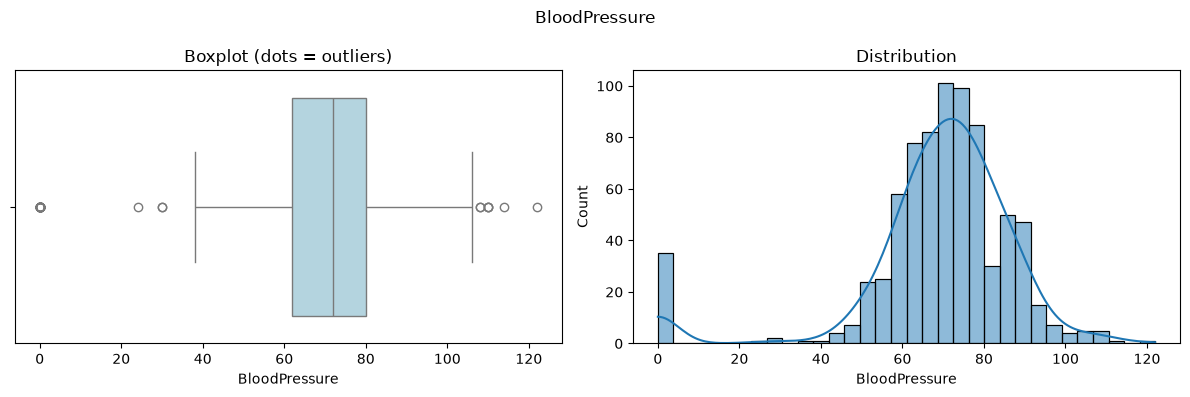

In [192]:
graphe_check_outliers(df, "BloodPressure")

In [193]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')


Pregnancies


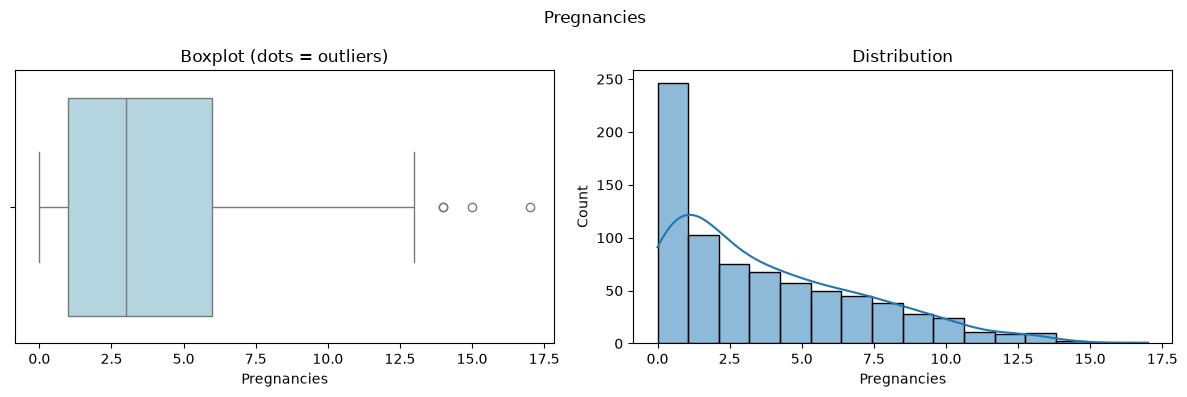

Glucose


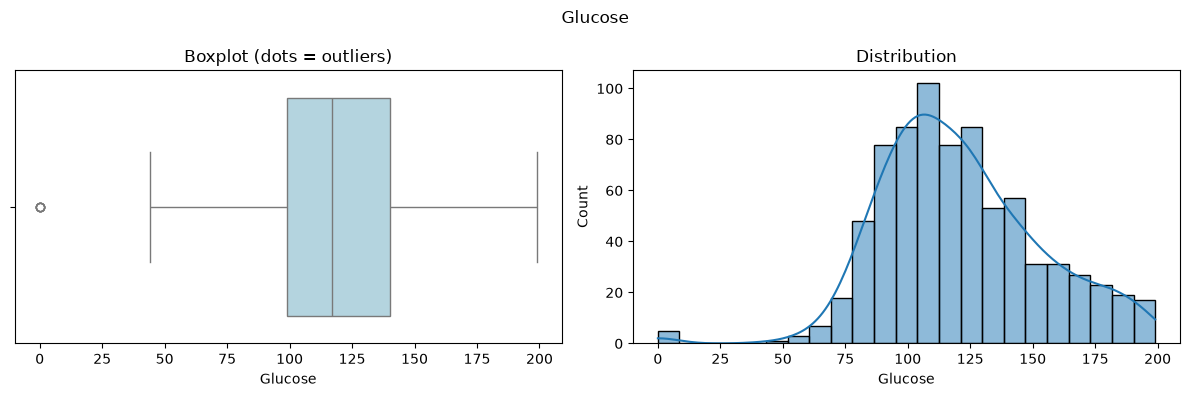

BloodPressure


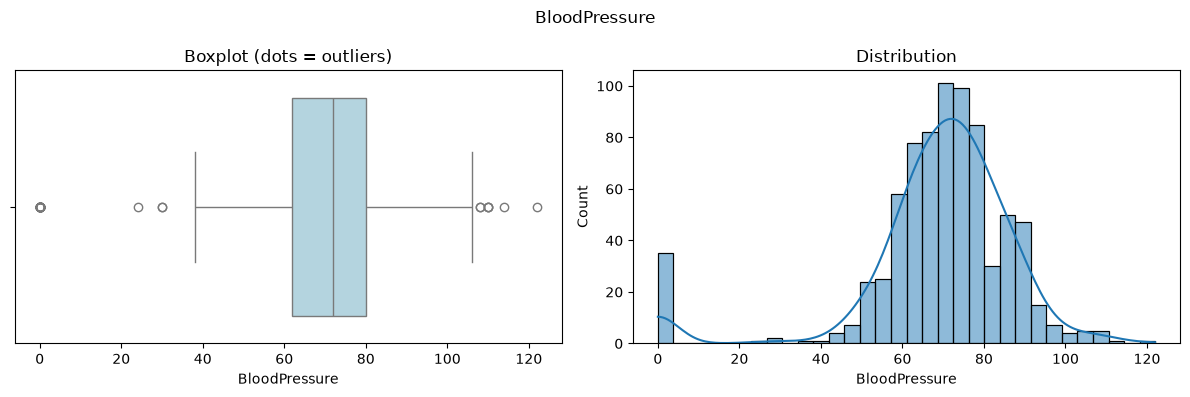

SkinThickness


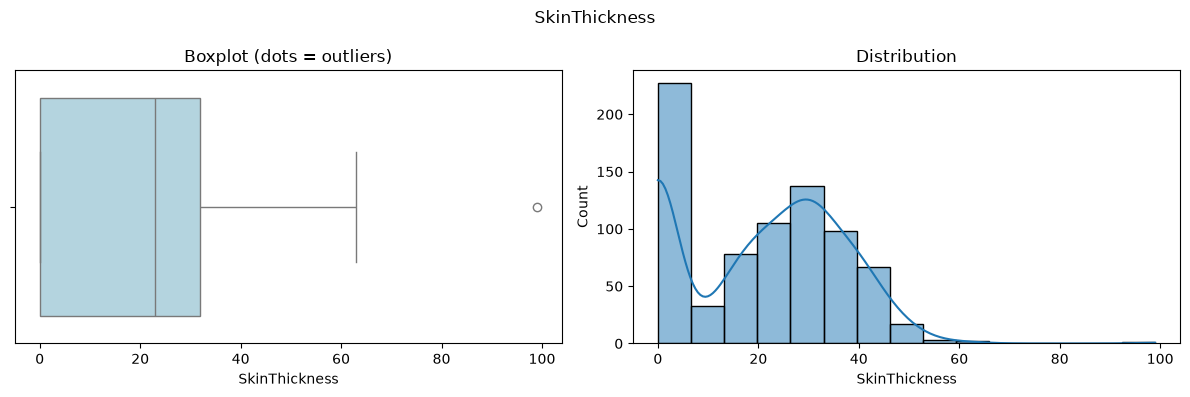

Insulin


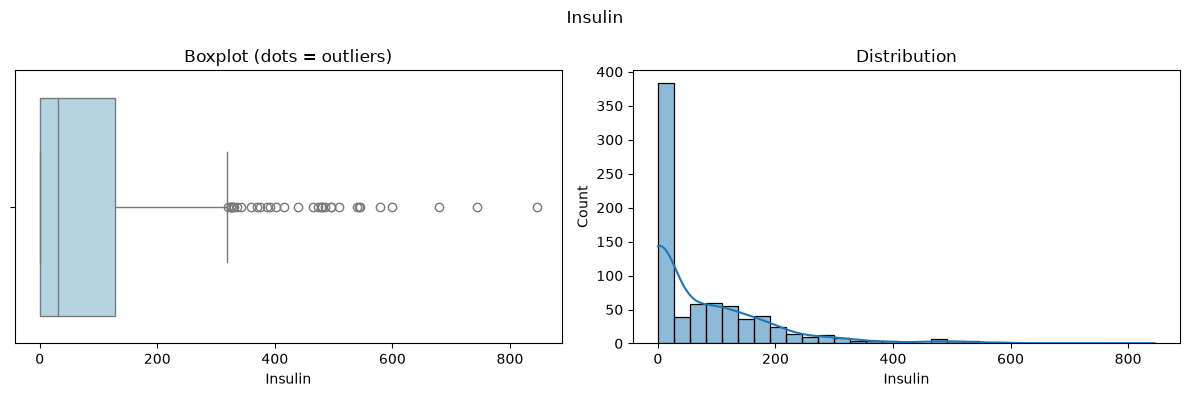

BMI


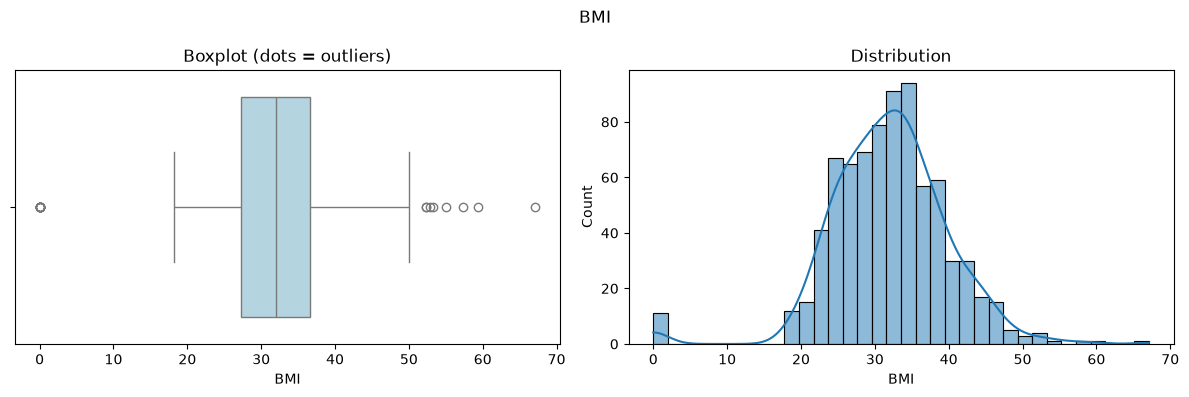

DiabetesPedigreeFunction


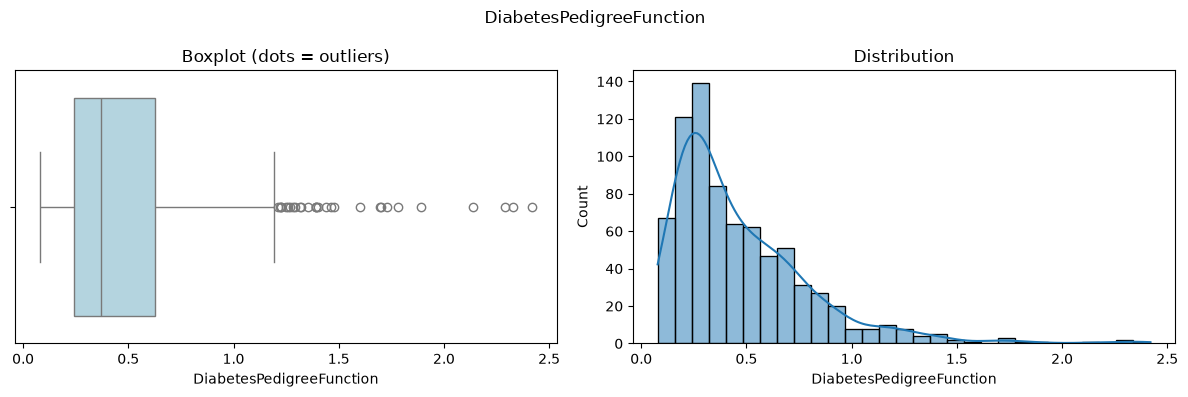

Age


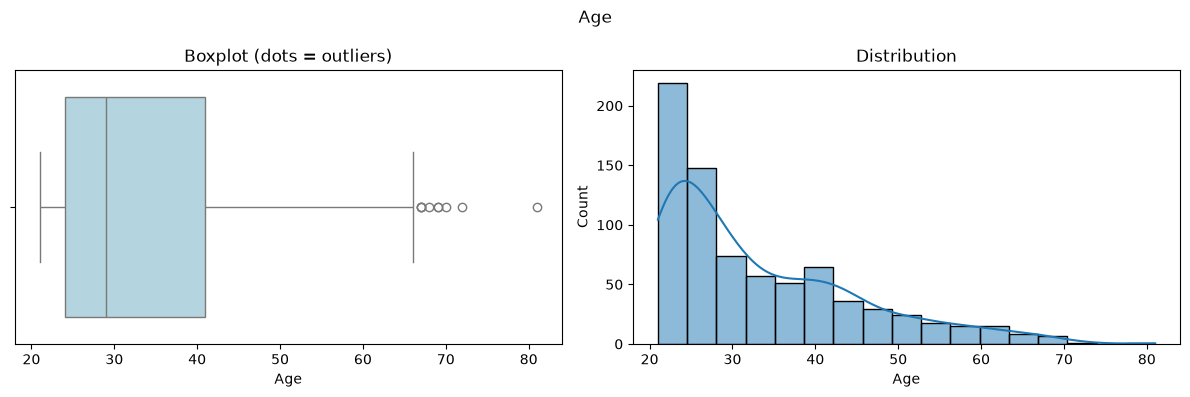

In [194]:
print("Pregnancies")
graphe_check_outliers(df, "Pregnancies")
print("Glucose")
graphe_check_outliers(df, "Glucose")
print("BloodPressure")
graphe_check_outliers(df, "BloodPressure")
print("SkinThickness")
graphe_check_outliers(df, "SkinThickness")
print("Insulin")
graphe_check_outliers(df, "Insulin")
print("BMI")
graphe_check_outliers(df, "BMI")
print("DiabetesPedigreeFunction")
graphe_check_outliers(df, "DiabetesPedigreeFunction")
print("Age")
graphe_check_outliers(df, "Age")


In [195]:
# df[df['Pregnancies']> 16]
df[df['Age'] > 65].count()

Pregnancies                 13
Glucose                     13
BloodPressure               13
SkinThickness               13
Insulin                     13
BMI                         13
DiabetesPedigreeFunction    13
Age                         13
dtype: int64

In [196]:
fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']

for c in fake_zero:
    df = zeros_to_nan(df, c)

In [197]:
df[fake_zero].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [198]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# scaled_value = scaler.fit_transform(df[fake_zero])

# df_scaled = df.copy()
# df_scaled[fake_zero] = scaled_value

# df_scaled[fake_zero].head()

In [199]:
# df_scaled[fake_zero].isna().sum()

In [200]:
# back into this part and try to use cross avlidation with this values 3,5,7 
# to find what is the bast value of neighbors
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# imputed_values = imputer.fit_transform(df_scaled[fake_zero])

In [201]:
imputed_values

array([[ 0.86228736, -0.03274557,  0.55855696,  0.34100541,  0.16509656],
       [-1.20222881, -0.51764464, -0.01465704, -0.69081731, -0.84640379],
       [ 2.0092408 , -0.67927766, -0.33947831,  0.52814973, -1.32325395],
       ...,
       [-0.02250528, -0.03274557, -0.58787104, -0.36710822, -0.90420381],
       [ 0.14134521, -1.00254371, -0.75983524,  0.26345011, -0.34065362],
       [-0.94006803, -0.19437859,  0.17641429, -0.41937375, -0.2973036 ]],
      shape=(768, 5))

In [202]:
np.isnan(imputed_values).sum()

np.int64(0)

In [203]:
# imputed_real = scaler.inverse_transform(imputed_values)
# imputed_real

In [204]:
# df_final = df.copy()
# df_final[fake_zero] = imputed_real

# df_final[fake_zero].head()

In [205]:
# df_final[fake_zero].isna().sum()
# df_final

In [206]:
# df_final[fake_zero].isna().sum()


In [207]:
# df_final[fake_zero].describe()

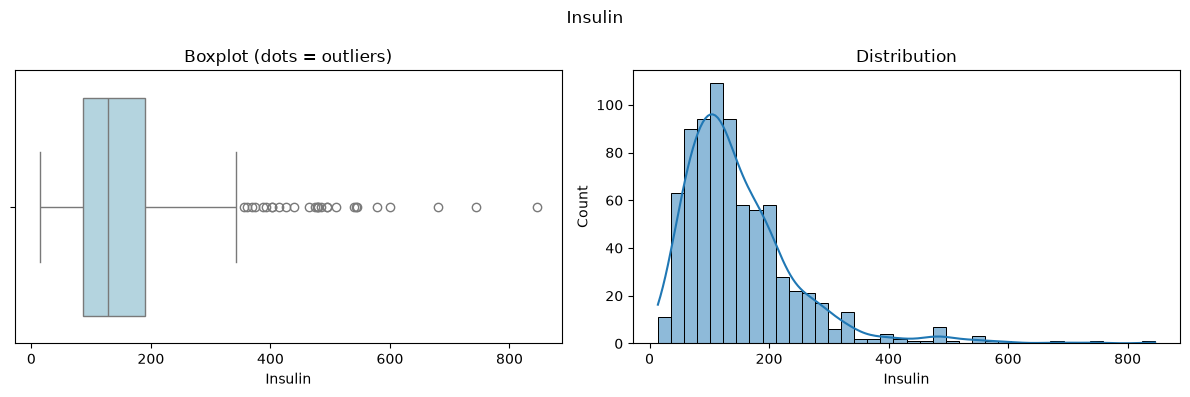

,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,471
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,14.0
6,Distribution,Max,846.0
7,Distribution,Mean,150.54
8,Distribution,Median,127.6
9,Distribution,Std deviation,97.41


In [208]:
graphe_check_outliers(df_final, "Insulin")
column_info(df_final, "Insulin")

In [209]:
fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_final = knn(df, fake_zero)
df_final[fake_zero].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.722656,72.467188,28.605729,150.538281,32.446146
std,30.454597,12.227699,9.558563,97.412594,6.889450
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,22.000000,87.000000,27.500000
50%,117.000000,72.000000,28.100000,127.600000,32.050000
75%,141.000000,80.000000,35.000000,189.850000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000
